In [ ]:
import sys
sys.path.append("../../src")

from models import PINN
from utils import derivative, get_device

In [2]:
import torch 
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt

device = get_device()

# creating the model

In [3]:
model = PINN(input_dim=2, hidden_dim=64, output_dim=1, num_layers=4)
if 'device' in globals():
    model = model.to(device)

In [4]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# describind pde

## intern points
#### minimize ut​−Duxx​=0

In [5]:
Nf = 5000

t_f = torch.rand(Nf, 1, device=device, requires_grad=True)
x_f = torch.rand(Nf, 1, device=device, requires_grad=True)

## boundary conditions

## x= 0
#### u(t,0) = 1

In [6]:
Nb = 1000
t_b1 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b1 = torch.zeros(Nb, 1, device=device, requires_grad=True)
u_b1_true = torch.ones(Nb,1, device=device) 

#### u(t,1) = 1

In [7]:
t_b2 = torch.rand(Nb,1, device=device, requires_grad=True)
x_b2 = torch.ones(Nb,1, device=device, requires_grad=True)
u_b2_true = torch.ones(Nb,1, device=device,)

## initial conditions
### u(0,x) = 0

In [8]:
Ni = 2000
t_i = torch.zeros(Ni, 1, device=device, requires_grad=True)
x_i = torch.rand(Ni,1, device=device, requires_grad=True)
u_i_true = torch.zeros(Ni,1, device=device,)

# Training

In [9]:
a = 0.1
epochs = 8000

for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE

    u_f = model(t_f, x_f)
    u_t = derivative(u_f, t_f)
    u_x = derivative(u_f, x_f)
    u_xx = derivative(u_x, x_f)

    # equation residual
    loss_pde = torch.mean((u_t - a * u_xx)**2)

    # bc conditions
    u_b1 = model(t_b1, x_b1)
    u_b2 = model(t_b2, x_b2)

    # bc residual
    loss_bc = (
        torch.mean((u_b1 - u_b1_true)**2)
        +
        torch.mean((u_b2 - u_b2_true)**2)
    )

    # initial conditions
    u_i = model(t_i, x_i)

    # initial residual
    loss_ic = torch.mean((u_i - u_i_true)**2)

    # TOTAL LOSS
    loss = (loss_pde + loss_bc + loss_ic)

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss_pde.item(), loss_bc.item(), loss_ic.item(), loss.item())

/home/warley/.venvs/ml/lib/python3.11/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


0 0.0009771330514922738 1.9449011087417603 0.0009661343647167087 1.946844458580017
1000 0.0045334049500525 0.021226484328508377 0.029977694153785706 0.055737584829330444
2000 0.002362732542678714 0.009324456565082073 0.009767062030732632 0.021454252302646637
3000 0.0018348509911447763 0.0073410384356975555 0.006725405342876911 0.015901293605566025
4000 0.001459482591599226 0.006072577089071274 0.00478480476886034 0.012316863983869553
5000 0.0007862240308895707 0.004519090987741947 0.0034125549718737602 0.008717870339751244
6000 0.0006668984424322844 0.003687509335577488 0.0026417323388159275 0.0069961403496563435
7000 0.000954395451117307 0.0032001491636037827 0.002159679541364312 0.006314224563539028


# Vizualizing
### creating the space

In [18]:
nx = 200
nt = 100

x = torch.linspace(0,1,nx)
t = torch.linspace(0,1,nt)

T, X = torch.meshgrid(t,x,indexing='ij')

x_test = X.reshape(-1,1).to(device)
t_test = T.reshape(-1,1).to(device)

with torch.no_grad():
    U = model(t_test, x_test)

U = U.reshape(nt,nx).cpu()

## graph

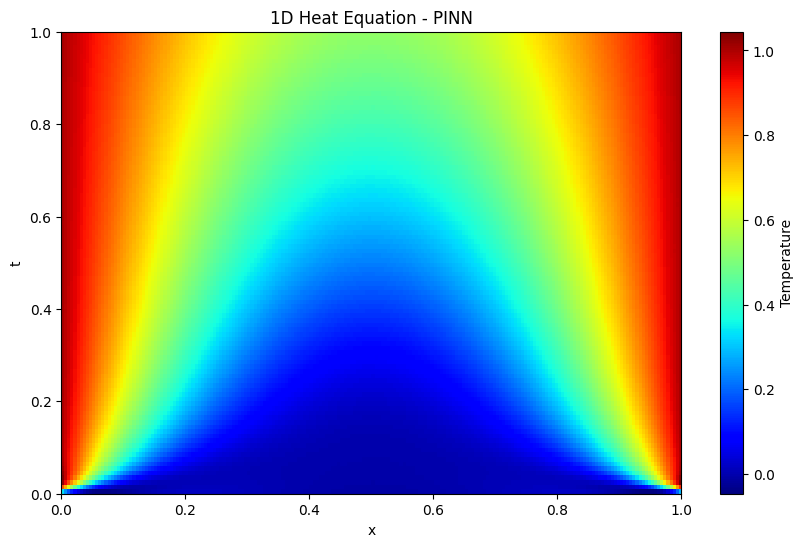

In [19]:
plot_1d_heatmap(U, filename='assets/edges_at_1deg/spatiotemporal_heatmap.png')

# 3D

In [12]:
from mpl_toolkits.mplot3d import Axes3D

In [13]:
nx = 100
nt = 100

x = torch.linspace(0,1,nx)

t = torch.linspace(0,1,nt)

T, X = torch.meshgrid(
    t,
    x,
    indexing='ij'
)

In [14]:
x_test = X.reshape(-1,1).to(device)

t_test = T.reshape(-1,1).to(device)

In [15]:
with torch.no_grad():

    U = model(
        t_test,
        x_test
    )

In [16]:
U = U.reshape(nt,nx).cpu()

U = U.numpy()

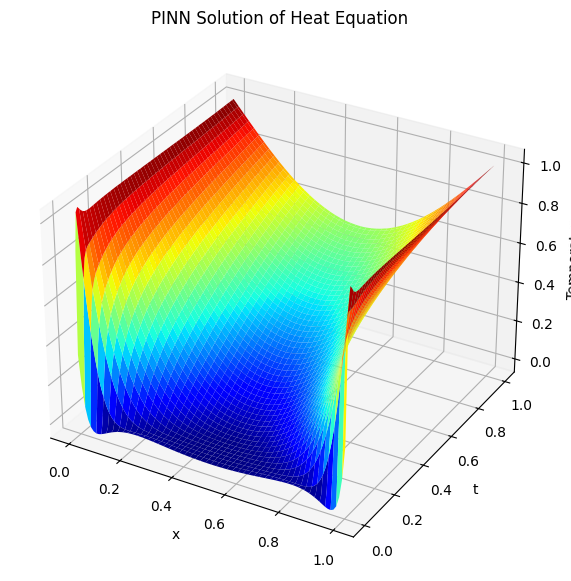

In [17]:
plot_1d_surface(X.numpy(), T.numpy(), U, filename='assets/edges_at_1deg/spatiotemporal_surface.png')